# Data Mining Project 2
## Shangwe


### Part A: Data Preprocessing

  

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, chi2
import time
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler




pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

df = pd.read_excel("Data/Telco_customer_churn.xlsx")
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
df.head()


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


I will first look at the basic structure of the dataset so I can see the number of features, the data types, and any missing values that may need to be handled later.


In [2]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values by column:")
print(df.isna().sum().sort_values(ascending=False))


Dataset shape: (7043, 33)

Column names:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']

Data types:
CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines      

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,7043,7043,3668-QPYBK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Count,7043.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
Country,7043,1,United States,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,7043,1,California,7043,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,7043,1129,Los Angeles,305,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Zip Code,7043.0,NaN,NaN,NaN,93521.964646,1865.794555,90001.0,92102.0,93552.0,95351.0,96161.0
Lat Long,7043,1652,"33.964131, -118.272783",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,7043.0,NaN,NaN,NaN,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,NaN,NaN,NaN,-119.79888,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Next, I will define the two response variables for the project. The first is the binary churn problem, and the second is a grouped churn category problem based on the reported churn reason. For the second problem, I will group the churn reasons into the four business categories Competitor, Price, Service/Support, and Other. Grouping the churn reasons this way makes the second problem more business relevant and easier to interpret.


In [4]:
churn_reason_map = {
    "Attitude of support person": "Service/Support",
    "Attitude of service provider": "Service/Support",
    "Competitor offered higher download speeds": "Competitor",
    "Competitor offered more data": "Competitor",
    "Competitor made better offer": "Competitor",
    "Competitor had better devices": "Competitor",
    "Price too high": "Price",
    "Extra data charges": "Price",
    "Lack of affordable download/upload speed": "Price",
    "Long distance charges": "Price",
    "Network reliability": "Service/Support",
    "Product dissatisfaction": "Service/Support",
    "Service dissatisfaction": "Service/Support",
    "Lack of self-service on Website": "Service/Support",
    "Poor expertise of phone support": "Service/Support",
    "Poor expertise of online support": "Service/Support",
    "Don't know": "Other",
    "Moved": "Other",
    "Limited range of services": "Other",
    "Deceased": "Other"
}

df["Churn Category"] = df["Churn Reason"].map(churn_reason_map)

print("Churn label counts:")
print(df["Churn Label"].value_counts(dropna=False))

print("\nRaw churn reason counts:")
print(df["Churn Reason"].value_counts(dropna=False))

print("\nGrouped churn category counts:")
print(df["Churn Category"].value_counts(dropna=False))


Churn label counts:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Raw churn reason counts:
Churn Reason
NaN                                          5174
Attitude of support person                    192
Competitor offered higher download speeds     189
Competitor offered more data                  162
Don't know                                    154
Competitor made better offer                  140
Attitude of service provider                  135
Competitor had better devices                 130
Network reliability                           103
Product dissatisfaction                       102
Price too high                                 98
Service dissatisfaction                        89
Lack of self-service on Website                88
Extra data charges                             57
Moved                                          53
Lack of affordable download/upload speed       44
Long distance charges                          44
Limited range of services    

I will now visualize the variables in the dataset. I am excluding only "CustomerID" because it is a self-identifier, but for the rest of the variables I want to look at distributions, categorical counts, and numeric relationships. 


In [5]:
viz_df = df.copy()

categorical_cols = [
    col for col in viz_df.columns
    if viz_df[col].dtype == "object" and col != "CustomerID"
]

numeric_cols = [
    col for col in viz_df.columns
    if col != "CustomerID" and pd.api.types.is_numeric_dtype(viz_df[col])
]

print("Categorical columns:")
print(categorical_cols)
print("\nNumeric columns:")
print(numeric_cols)

high_cardinality_cols = {"City", "Zip Code", "Lat Long", "Churn Reason"}

Categorical columns:
['Country', 'State', 'City', 'Lat Long', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Churn Label', 'Churn Reason', 'Churn Category']

Numeric columns:
['Count', 'Zip Code', 'Latitude', 'Longitude', 'Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value', 'Churn Score', 'CLTV']


I will first plot the categorical variables.


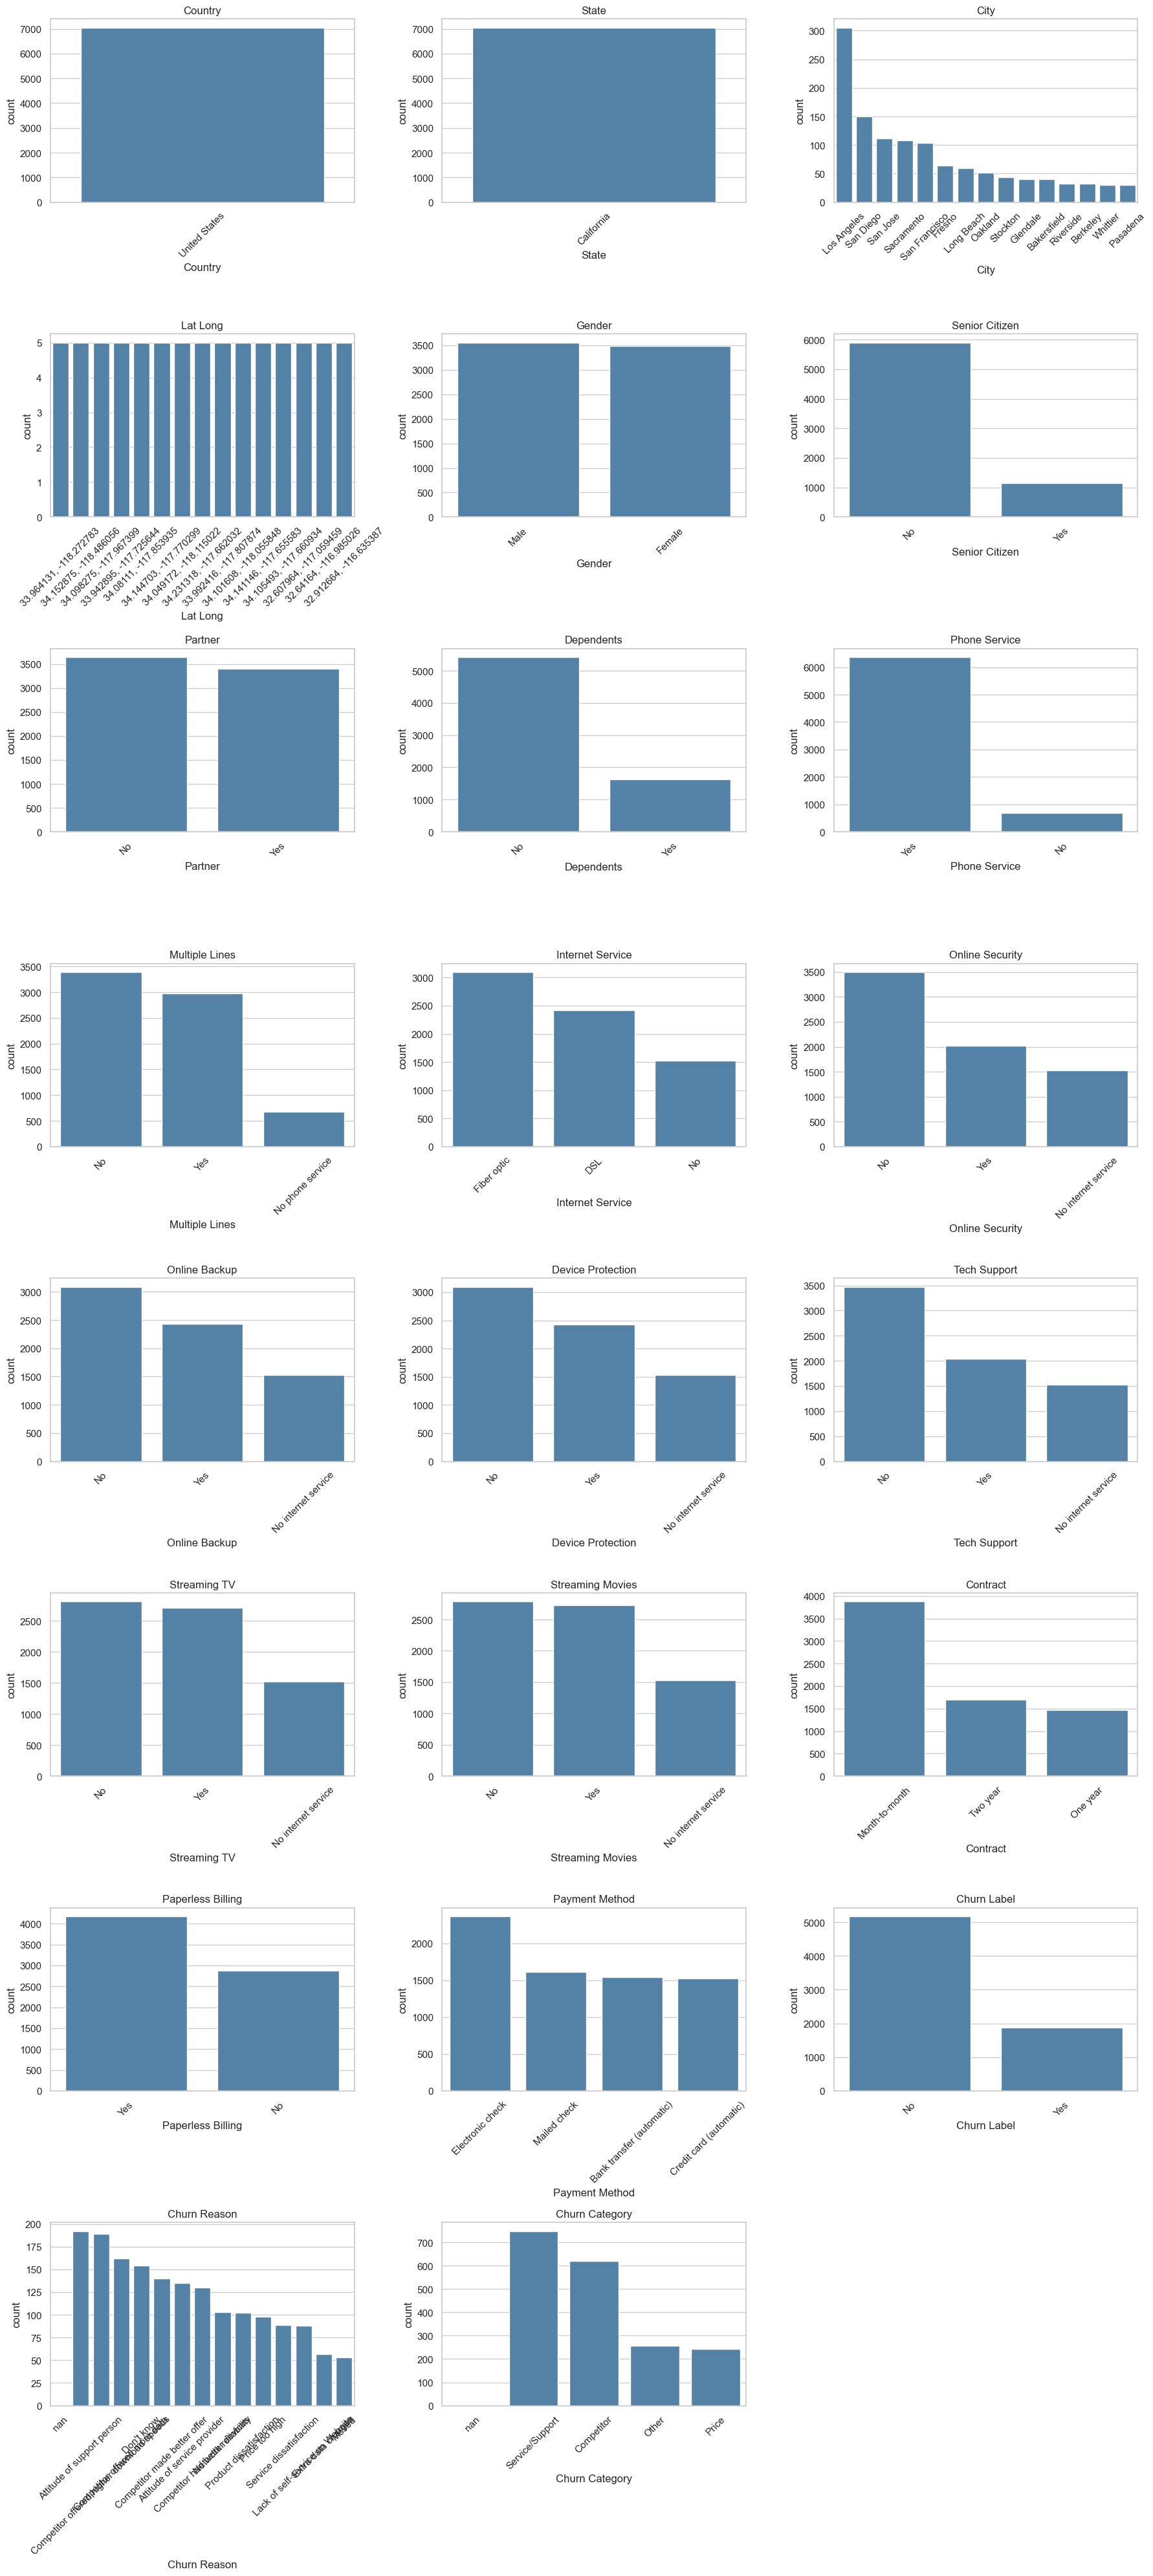

In [6]:
n_cols = 3
n_rows = int(np.ceil(len(categorical_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    order = viz_df[col].value_counts(dropna=False).index
    plot_df = viz_df.copy()
    if col in high_cardinality_cols:
        top_values = viz_df[col].value_counts(dropna=False).head(15).index
        plot_df = plot_df[plot_df[col].isin(top_values)]
        order = plot_df[col].value_counts(dropna=False).index
    sns.countplot(data=plot_df, x=col, order=order, ax=ax, color="steelblue")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


Next, I will plot the numeric variable distributions so I can see which ones are skewed and which ones are more evenly spread out.


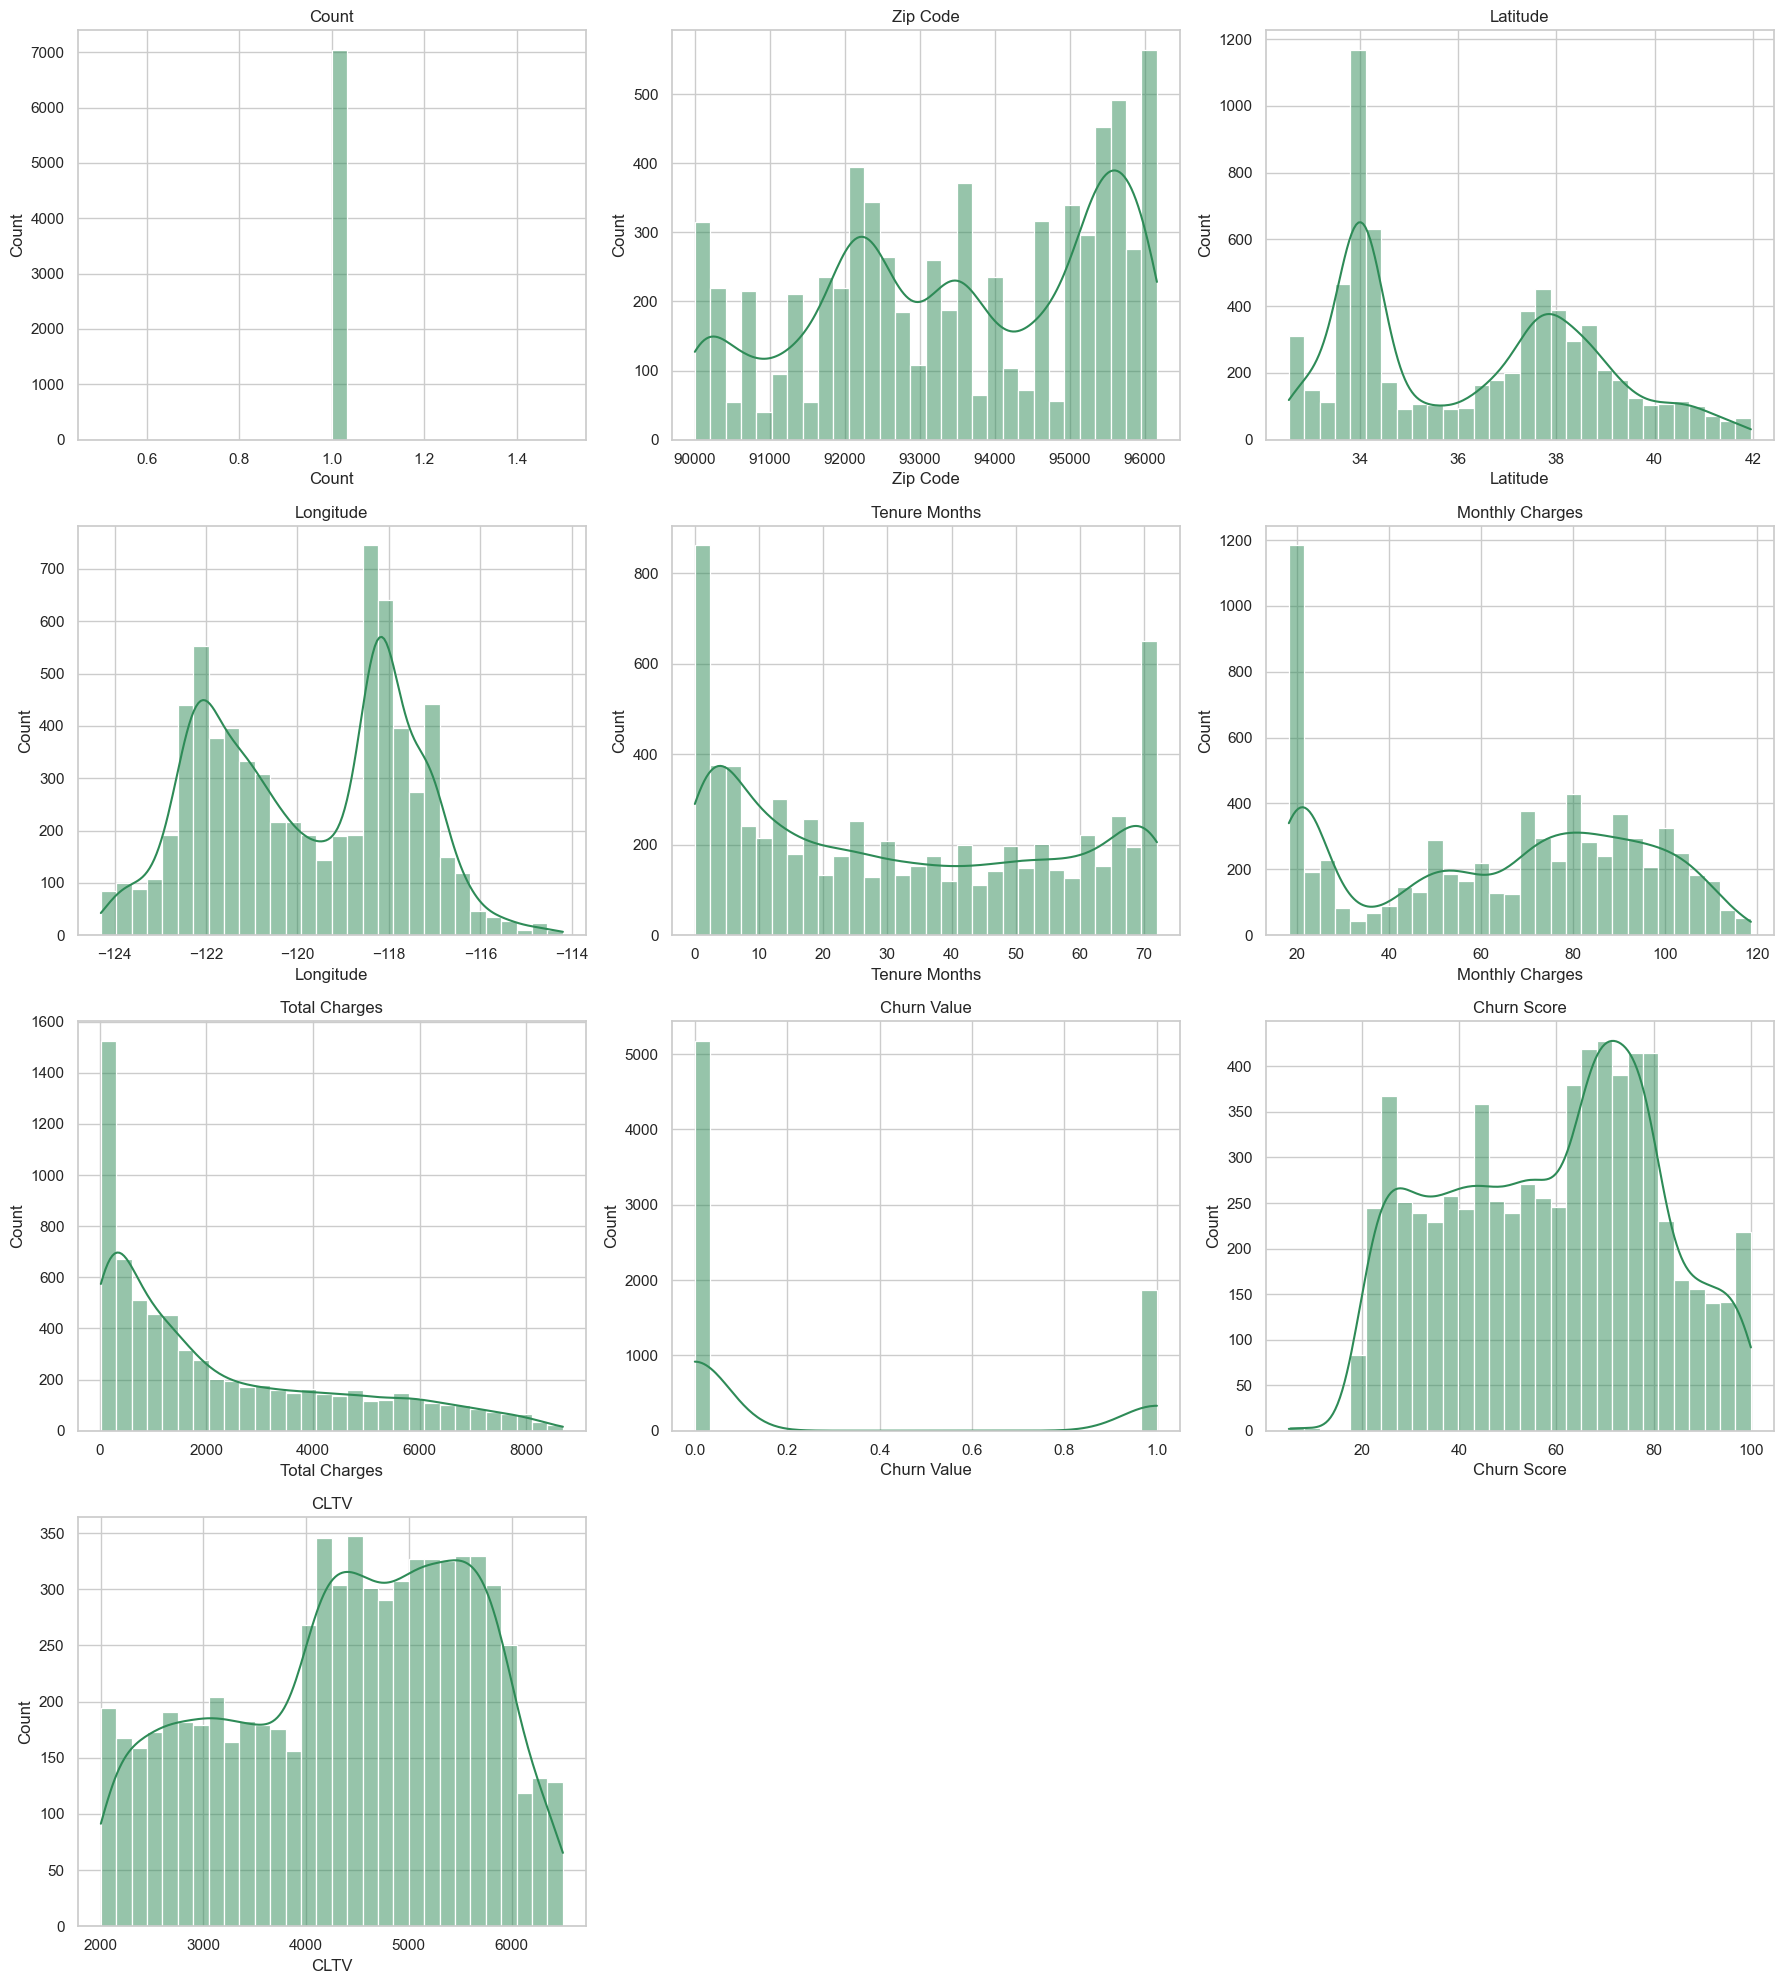

In [7]:
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    sns.histplot(viz_df[col].dropna(), bins=30, kde=True, ax=ax, color="seagreen")
    ax.set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


I willa also create some boxplots comparing key business variables to churn, since it can show whether there is visible separation between customers who stayed and customers who churned.


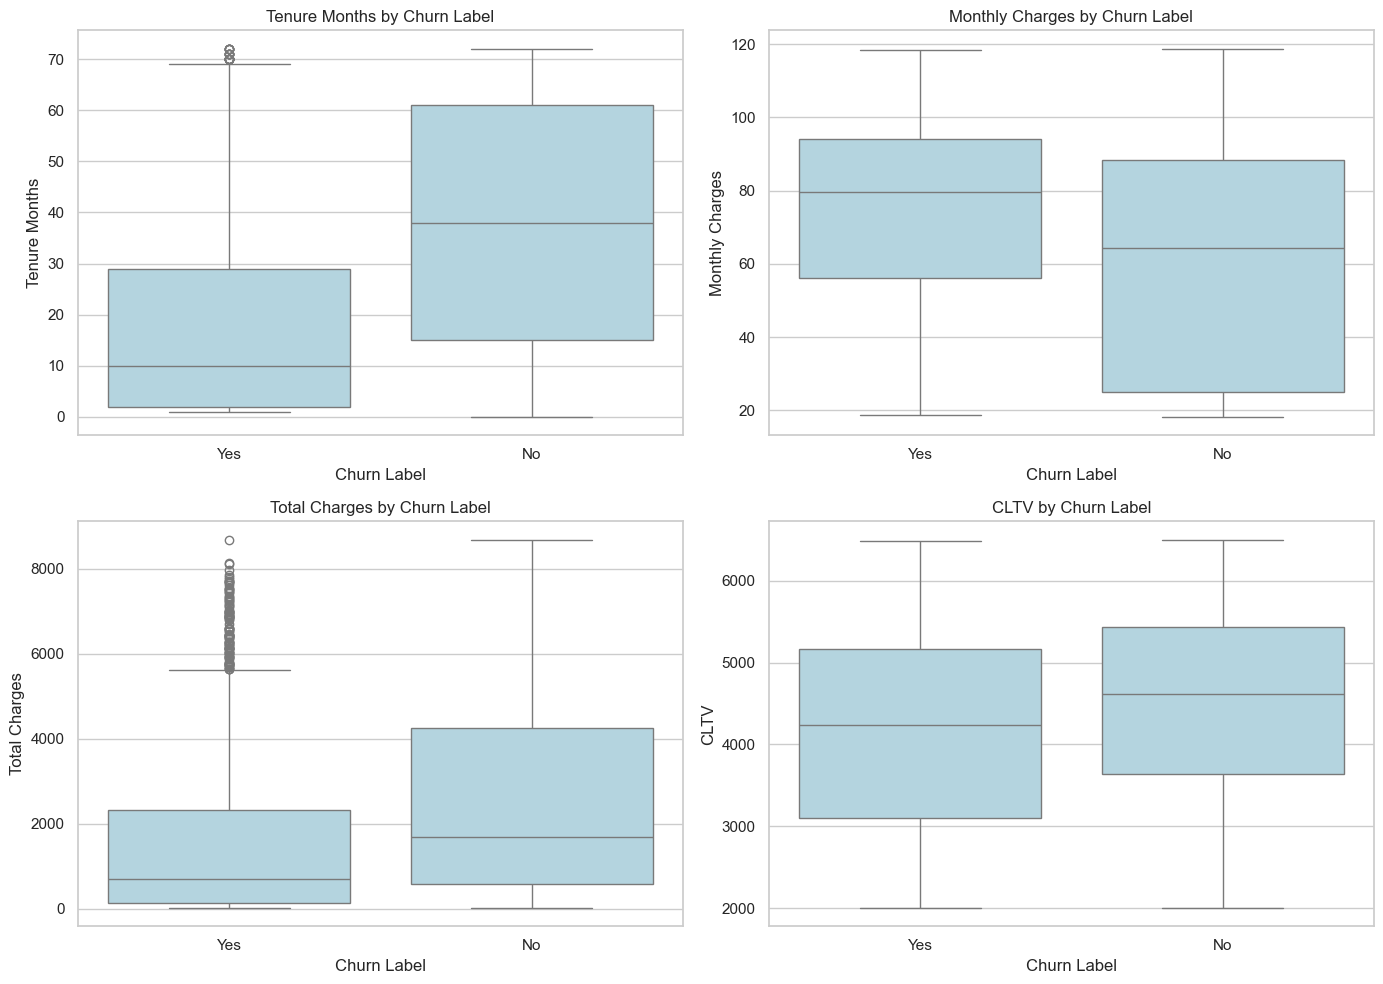

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
boxplot_cols = ["Tenure Months", "Monthly Charges", "Total Charges", "CLTV"]

for ax, col in zip(axes.flatten(), boxplot_cols):
    sns.boxplot(data=viz_df, x="Churn Label", y=col, ax=ax, color="lightblue")
    ax.set_title(f"{col} by Churn Label")

plt.tight_layout()
plt.show()


Finally, I will look at the correlation matrix for the numeric variables to see which numeric features move together more strongly.


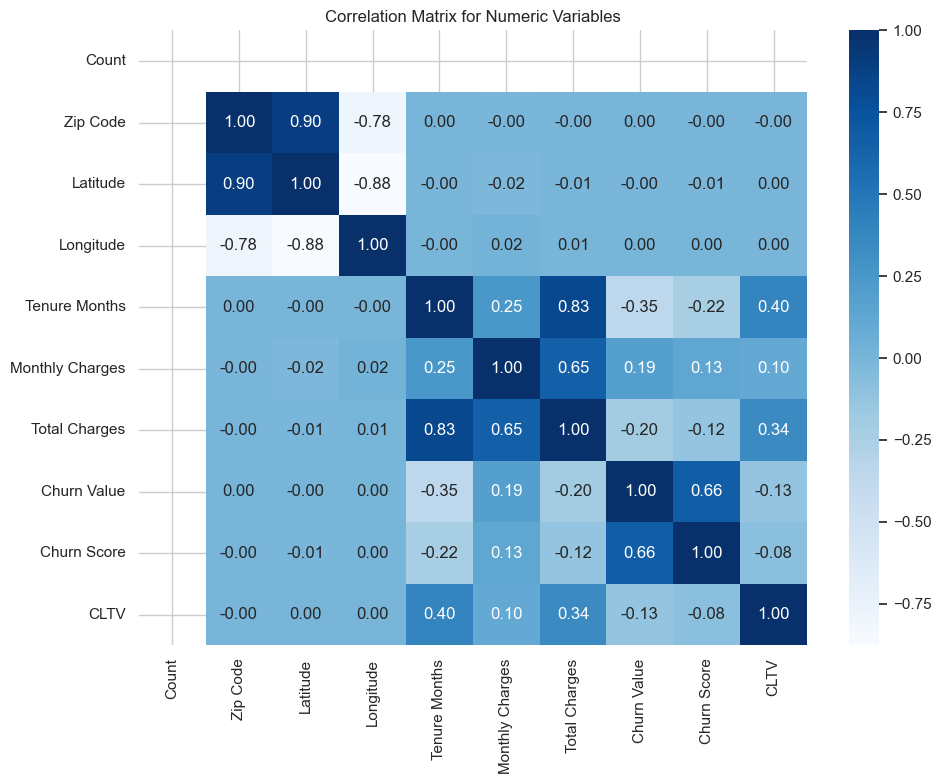

In [9]:
plt.figure(figsize=(10, 8))
corr = viz_df[numeric_cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix for Numeric Variables")
plt.tight_layout()
plt.show()


/var/folders/mq/8yjy6rpx2sl_zhhncpvt8cwm0000gn/T/ipykernel_27441/3299782021.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=contract_churn_rates, x="Contract", y="Churn Rate", ax=axes[0], palette="crest")
/var/folders/mq/8yjy6rpx2sl_zhhncpvt8cwm0000gn/T/ipykernel_27441/3299782021.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tenure_stage_churn_rates, x="Tenure Stage", y="Churn Rate", ax=axes[1], palette="flare")
/var/folders/mq/8yjy6rpx2sl_zhhncpvt8cwm0000gn/T/ipykernel_27441/3299782021.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same eff

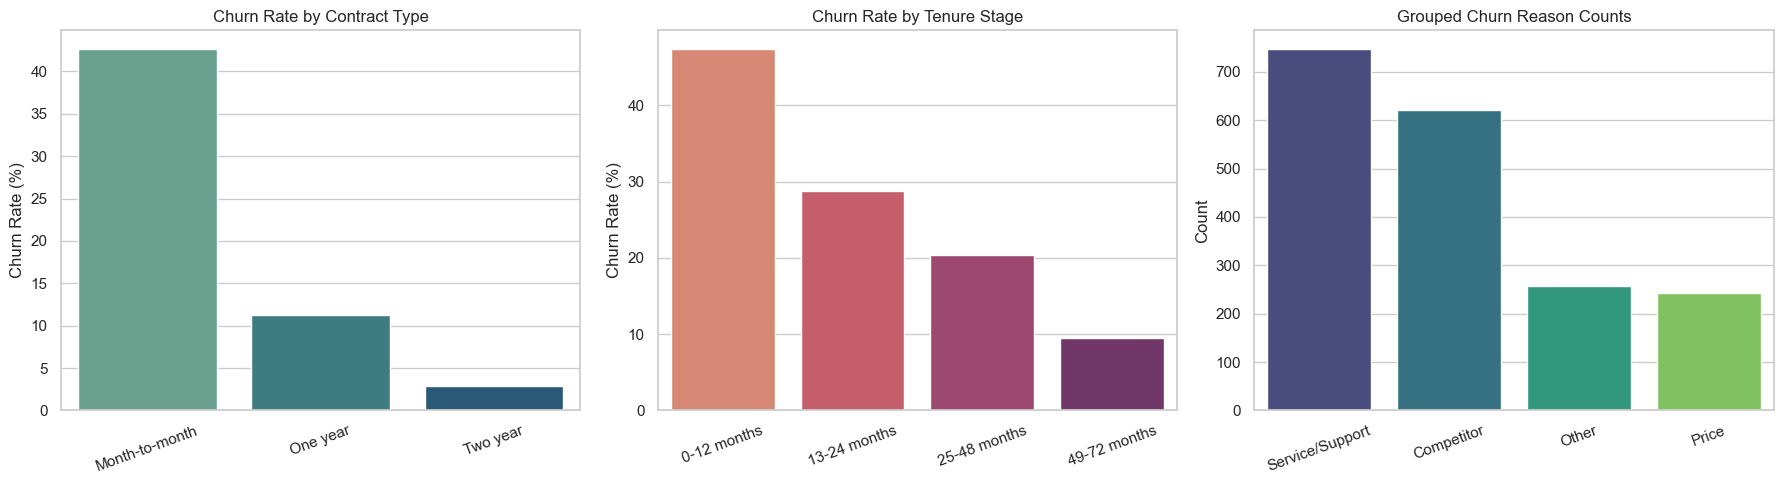

In [10]:
focused_eda_df = df.copy()

focused_eda_df["Tenure Stage"] = pd.cut(
    focused_eda_df["Tenure Months"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12 months", "13-24 months", "25-48 months", "49-72 months"]
)

contract_churn_rates = (
    focused_eda_df.groupby("Contract")["Churn Value"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .reset_index(name="Churn Rate")
)

tenure_stage_churn_rates = (
    focused_eda_df.groupby("Tenure Stage", observed=False)["Churn Value"]
    .mean()
    .mul(100)
    .reset_index(name="Churn Rate")
)

grouped_reason_counts = (
    focused_eda_df["Churn Category"]
    .dropna()
    .value_counts()
    .rename_axis("Churn Category")
    .reset_index(name="Count")
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=contract_churn_rates, x="Contract", y="Churn Rate", ax=axes[0], palette="crest")
axes[0].set_title("Churn Rate by Contract Type")
axes[0].set_ylabel("Churn Rate (%)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(data=tenure_stage_churn_rates, x="Tenure Stage", y="Churn Rate", ax=axes[1], palette="flare")
axes[1].set_title("Churn Rate by Tenure Stage")
axes[1].set_ylabel("Churn Rate (%)")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(data=grouped_reason_counts, x="Churn Category", y="Count", ax=axes[2], palette="viridis")
axes[2].set_title("Grouped Churn Reason Counts")
axes[2].set_ylabel("Count")
axes[2].set_xlabel("")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

Now I will preprocess the dataset for the first classification problem, which is binary churn prediction. I will remove identifier and leakage-related columns, fill in any remaining missing values, and then create a stratified 90/10 train-test split.


In [11]:
processed_dir = "ProcessedTelcoData"
os.makedirs(processed_dir, exist_ok=True)

churn_df = df.copy()

churn_drop_cols = [
    "CustomerID", "Count", "Country", "State", "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Value", "Churn Score", "Churn Reason", "Churn Category"
]

churn_df = churn_df.drop(columns=churn_drop_cols)

for col in churn_df.columns:
    if col == "Churn Label":
        continue
    if churn_df[col].dtype == "object":
        churn_df[col] = churn_df[col].fillna("Unknown")
    else:
        churn_df[col] = churn_df[col].fillna(churn_df[col].median())

churn_feature_cols = [col for col in churn_df.columns if col != "Churn Label"]
churn_df = churn_df[churn_feature_cols + ["Churn Label"]]

churn_train_df, churn_test_df = train_test_split(
    churn_df,
    test_size=0.10,
    random_state=42,
    stratify=churn_df["Churn Label"]
)

churn_train_df = churn_train_df.reset_index(drop=True)
churn_test_df = churn_test_df.reset_index(drop=True)

churn_df.to_csv(f"{processed_dir}/churn_processed_full.csv", index=False)
churn_train_df.to_csv(f"{processed_dir}/churn_train.csv", index=False)
churn_test_df.to_csv(f"{processed_dir}/churn_test.csv", index=False)

print("Churn full processed dataset shape:", churn_df.shape)
print("\nChurn missing values after preprocessing:")
print(churn_df.isna().sum().sort_values(ascending=False).head())
print("\nChurn class counts:")
print(churn_df["Churn Label"].value_counts())
print("\nChurn training set shape:", churn_train_df.shape)
print("Churn test set shape:", churn_test_df.shape)


Churn full processed dataset shape: (7043, 22)

Churn missing values after preprocessing:
City               0
Gender             0
CLTV               0
Total Charges      0
Monthly Charges    0
dtype: int64

Churn class counts:
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64

Churn training set shape: (6338, 22)
Churn test set shape: (705, 22)


Next, I will preprocess the second classification problem, which is grouped churn category. For this problem, I only use customers who churned and have a valid grouped churn category. I then remove leakage-related columns and create a second stratified 90/10 train-test split.


In [12]:
churn_category_df = df[(df["Churn Label"] == "Yes") & (df["Churn Category"].notna())].copy()

churn_category_drop_cols = [
    "CustomerID", "Count", "Country", "State", "Zip Code", "Lat Long", "Latitude", "Longitude",
    "Churn Label", "Churn Value", "Churn Score", "Churn Reason"
]

churn_category_df = churn_category_df.drop(columns=churn_category_drop_cols)

for col in churn_category_df.columns:
    if col == "Churn Category":
        continue
    if churn_category_df[col].dtype == "object":
        churn_category_df[col] = churn_category_df[col].fillna("Unknown")
    else:
        churn_category_df[col] = churn_category_df[col].fillna(churn_category_df[col].median())

churn_category_feature_cols = [col for col in churn_category_df.columns if col != "Churn Category"]
churn_category_df = churn_category_df[churn_category_feature_cols + ["Churn Category"]]

churn_category_train_df, churn_category_test_df = train_test_split(
    churn_category_df,
    test_size=0.10,
    random_state=42,
    stratify=churn_category_df["Churn Category"]
)

churn_category_train_df = churn_category_train_df.reset_index(drop=True)
churn_category_test_df = churn_category_test_df.reset_index(drop=True)

churn_category_df.to_csv(f"{processed_dir}/churn_category_processed_full.csv", index=False)
churn_category_train_df.to_csv(f"{processed_dir}/churn_category_train.csv", index=False)
churn_category_test_df.to_csv(f"{processed_dir}/churn_category_test.csv", index=False)

print("Churn category full processed dataset shape:", churn_category_df.shape)
print("\nChurn category missing values after preprocessing:")
print(churn_category_df.isna().sum().sort_values(ascending=False).head())
print("\nChurn category class counts:")
print(churn_category_df["Churn Category"].value_counts())
print("\nChurn category training set shape:", churn_category_train_df.shape)
print("Churn category test set shape:", churn_category_test_df.shape)


Churn category full processed dataset shape: (1869, 22)

Churn category missing values after preprocessing:
City               0
Gender             0
CLTV               0
Total Charges      0
Monthly Charges    0
dtype: int64

Churn category class counts:
Churn Category
Service/Support    748
Competitor         621
Other              257
Price              243
Name: count, dtype: int64

Churn category training set shape: (1682, 22)
Churn category test set shape: (187, 22)


### Part B (Model Fitting)

In [13]:
churn_train_df = pd.read_csv(f"{processed_dir}/churn_train.csv")
churn_test_df = pd.read_csv(f"{processed_dir}/churn_test.csv")
churn_category_train_df = pd.read_csv(f"{processed_dir}/churn_category_train.csv")
churn_category_test_df = pd.read_csv(f"{processed_dir}/churn_category_test.csv")

print("Churn training shape:", churn_train_df.shape)
print("Churn validation shape:", churn_test_df.shape)
print("\nChurn category training shape:", churn_category_train_df.shape)
print("Churn category validation shape:", churn_category_test_df.shape)


Churn training shape: (6338, 22)
Churn validation shape: (705, 22)

Churn category training shape: (1682, 22)
Churn category validation shape: (187, 22)


In [14]:
decision_tree_depths = [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 18, 20, 25, 30, 35, 40, 50, 60, None]
random_forest_estimators = [10, 20, 30, 40, 50, 75, 100, 125, 150, 175, 200, 225, 250, 300, 350, 400]

print("Decision Tree max_depth values:", decision_tree_depths)
print("\nRandom Forest n_estimators values:", random_forest_estimators)


Decision Tree max_depth values: [2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 18, 20, 25, 30, 35, 40, 50, 60, None]

Random Forest n_estimators values: [10, 20, 30, 40, 50, 75, 100, 125, 150, 175, 200, 225, 250, 300, 350, 400]


In [15]:
def plot_cv_results(param_values, mean_scores, title, xlabel, color, save_name):
    plt.figure(figsize=(10, 6))
    plot_values = ["None" if value is None else str(value) for value in param_values]
    plt.plot(plot_values, mean_scores, marker="o", color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Mean CV Accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


For the first classification problem, I will use the churn training dataset and tune the Decision Tree model first.

In [16]:
X_train_churn = churn_train_df.drop(columns=["Churn Label"])
y_train_churn = churn_train_df["Churn Label"]

categorical_cols_churn = X_train_churn.select_dtypes(include="object").columns.tolist()
numeric_cols_churn = X_train_churn.select_dtypes(exclude="object").columns.tolist()

churn_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols_churn),
        ("numeric", "passthrough", numeric_cols_churn)
    ]
)

churn_decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", churn_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

churn_decision_tree_grid = GridSearchCV(
    churn_decision_tree_pipeline,
    param_grid={"model__max_depth": decision_tree_depths},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

churn_decision_tree_grid.fit(X_train_churn, y_train_churn)
churn_decision_tree_results = pd.DataFrame(churn_decision_tree_grid.cv_results_)
churn_decision_tree_scores = churn_decision_tree_results["mean_test_score"].tolist()



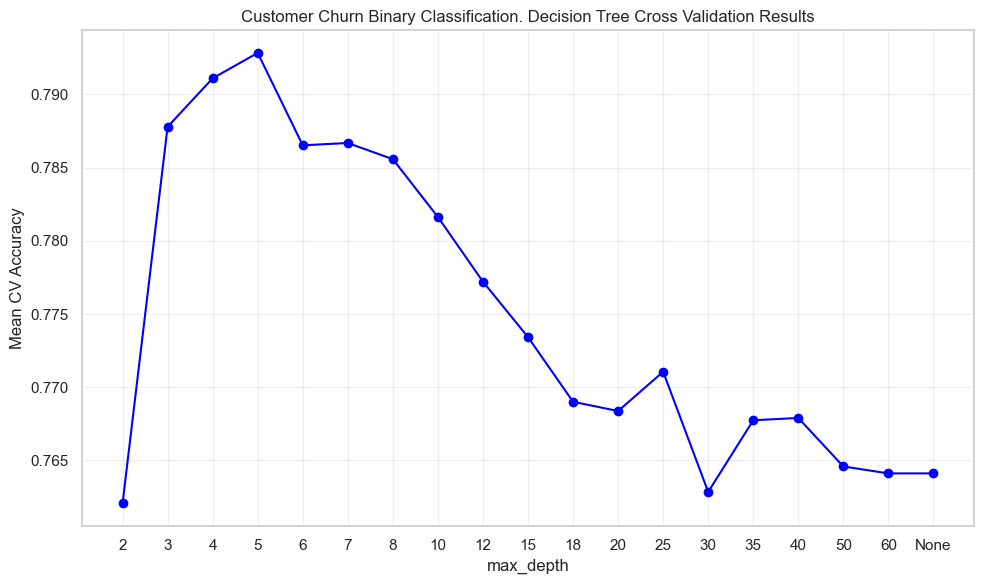

Churn problem Decision Tree best max_depth: 5
Churn problem Decision Tree best mean CV accuracy: 0.7928


In [17]:
plot_cv_results(
    decision_tree_depths,
    churn_decision_tree_scores,
    title="Customer Churn Binary Classification. Decision Tree Cross Validation Results",
    xlabel="max_depth",
    color="blue",
    save_name="churn_decision_tree_cv.png"
)
print("Churn problem Decision Tree best max_depth:", churn_decision_tree_grid.best_params_["model__max_depth"])
print("Churn problem Decision Tree best mean CV accuracy:", round(churn_decision_tree_grid.best_score_, 4))


Next, I will use the same churn training dataset to tune the Random Forest model.

In [18]:
churn_random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", churn_preprocessor),
    ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
])

churn_random_forest_grid = GridSearchCV(
    churn_random_forest_pipeline,
    param_grid={"model__n_estimators": random_forest_estimators},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

churn_random_forest_grid.fit(X_train_churn, y_train_churn)
churn_random_forest_results = pd.DataFrame(churn_random_forest_grid.cv_results_)
churn_random_forest_scores = churn_random_forest_results["mean_test_score"].tolist()

print("Churn problem Random Forest best parameter:", churn_random_forest_grid.best_params_["model__n_estimators"])
print("Churn problem Random Forest best mean CV accuracy:", round(churn_random_forest_grid.best_score_, 4))


Churn problem Random Forest best parameter: 125
Churn problem Random Forest best mean CV accuracy: 0.8047


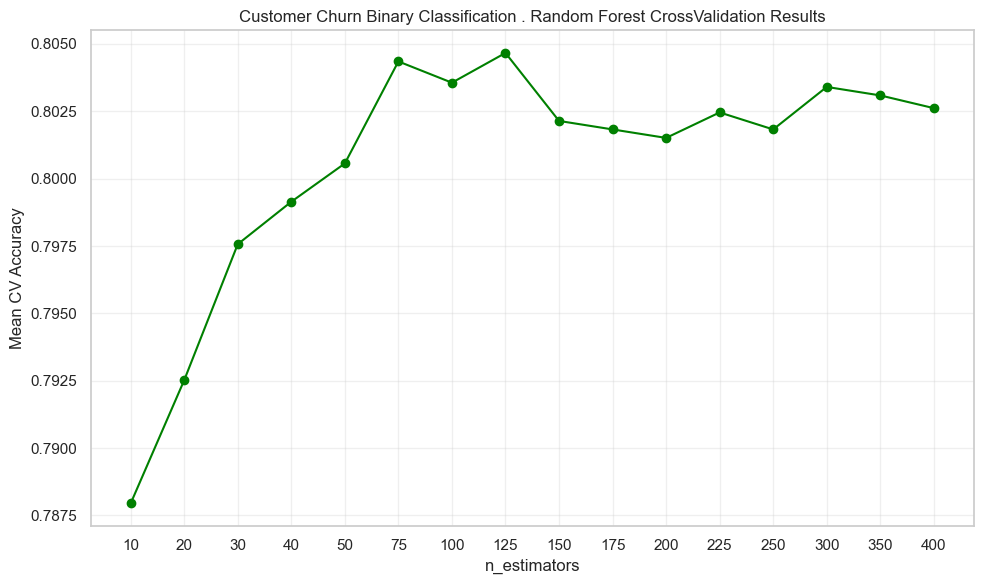

Churn problem Random Forest best n_estimators: 125
Churn problem Random Forest best mean CV accuracy: 0.8047


In [19]:
plot_cv_results(
    random_forest_estimators,
    churn_random_forest_scores,
    title="Customer Churn Binary Classification . Random Forest CrossValidation Results",
    xlabel="n_estimators",
    color="green",
    save_name="churn_random_forest_cv.png"
)
print("Churn problem Random Forest best n_estimators:", churn_random_forest_grid.best_params_["model__n_estimators"])
print("Churn problem Random Forest best mean CV accuracy:", round(churn_random_forest_grid.best_score_, 4))


In [20]:
print("Best hyperparameter values for the churn problem:")
print("Decision Tree max_depth =", churn_decision_tree_grid.best_params_["model__max_depth"])
print("Random Forest n_estimators =", churn_random_forest_grid.best_params_["model__n_estimators"])


Best hyperparameter values for the churn problem:
Decision Tree max_depth = 5
Random Forest n_estimators = 125


Now I will repeat the same process for the second classification problem, which is the grouped churn category problem. Before tuning the models, I will create a small set of engineered features that capture contract risk, service density, and spending intensity because the earlier EDA suggests these may help separate the churn categories more clearly.

In [21]:
def add_churn_reason_features(input_df):
    feature_df = input_df.copy()
    support_cols = ["Online Security", "Online Backup", "Device Protection", "Tech Support"]
    streaming_cols = ["Streaming TV", "Streaming Movies"]
    service_yes_no_cols = [
        "Phone Service", "Multiple Lines", "Online Security", "Online Backup",
        "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies"
    ]
    yes_like = {"Yes", "DSL", "Fiber optic"}

    feature_df["has_phone"] = (feature_df["Phone Service"] == "Yes").astype(int)
    feature_df["has_multiple_lines"] = (feature_df["Multiple Lines"] == "Yes").astype(int)
    feature_df["has_internet"] = (feature_df["Internet Service"] != "No").astype(int)
    feature_df["has_fiber"] = (feature_df["Internet Service"] == "Fiber optic").astype(int)
    feature_df["has_dsl"] = (feature_df["Internet Service"] == "DSL").astype(int)
    feature_df["is_month_to_month"] = (feature_df["Contract"] == "Month-to-month").astype(int)
    feature_df["electronic_check_flag"] = (feature_df["Payment Method"] == "Electronic check").astype(int)

    for col in service_yes_no_cols:
        feature_df[f"{col}_active_flag"] = feature_df[col].isin(yes_like).astype(int)

    feature_df["support_service_count"] = sum(feature_df[col].eq("Yes").astype(int) for col in support_cols)
    feature_df["streaming_service_count"] = sum(feature_df[col].eq("Yes").astype(int) for col in streaming_cols)
    feature_df["extra_service_count"] = (
        feature_df["support_service_count"] + feature_df["streaming_service_count"] + feature_df["has_multiple_lines"]
    )
    feature_df["total_service_count"] = (
        feature_df["has_phone"] + feature_df["has_multiple_lines"] + feature_df["has_internet"]
        + feature_df["support_service_count"] + feature_df["streaming_service_count"]
    )

    service_denom = feature_df["total_service_count"].replace(0, 1)
    tenure_denom = feature_df["Tenure Months"].replace(0, 1)
    feature_df["monthly_charge_per_service"] = feature_df["Monthly Charges"] / service_denom
    feature_df["total_charge_per_tenure"] = feature_df["Total Charges"] / tenure_denom
    feature_df["charges_gap"] = feature_df["Total Charges"] - feature_df["Monthly Charges"] * feature_df["Tenure Months"]

    return feature_df


X_train_churn_category_base = churn_category_train_df.drop(columns=["Churn Category"])
y_train_churn_category = churn_category_train_df["Churn Category"]
X_val_churn_category_base = churn_category_test_df.drop(columns=["Churn Category"])
y_val_churn_category = churn_category_test_df["Churn Category"]

X_train_churn_category = add_churn_reason_features(X_train_churn_category_base)
X_val_churn_category = add_churn_reason_features(X_val_churn_category_base)

categorical_cols_churn_category = X_train_churn_category.select_dtypes(include="object").columns.tolist()
numeric_cols_churn_category = X_train_churn_category.select_dtypes(exclude="object").columns.tolist()

churn_category_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols_churn_category),
        ("numeric", "passthrough", numeric_cols_churn_category)
    ]
)

churn_category_random_forest_depths = [8, 10, 12, 15, 18, 20, 25, 27, 30]

churn_category_decision_tree_pipeline = Pipeline(steps=[
    ("preprocessor", churn_category_preprocessor),
    ("model", DecisionTreeClassifier(random_state=42))
])

churn_category_decision_tree_grid = GridSearchCV(
    churn_category_decision_tree_pipeline,
    param_grid={"model__max_depth": decision_tree_depths},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

churn_category_decision_tree_grid.fit(X_train_churn_category, y_train_churn_category)
churn_category_decision_tree_results = pd.DataFrame(churn_category_decision_tree_grid.cv_results_)
churn_category_decision_tree_scores = churn_category_decision_tree_results["mean_test_score"].tolist()

print("Churn category Decision Tree best parameter:", churn_category_decision_tree_grid.best_params_["model__max_depth"])
print("Churn category Decision Tree best mean CV accuracy:", round(churn_category_decision_tree_grid.best_score_, 4))

Churn category Decision Tree best parameter: 4
Churn category Decision Tree best mean CV accuracy: 0.4084


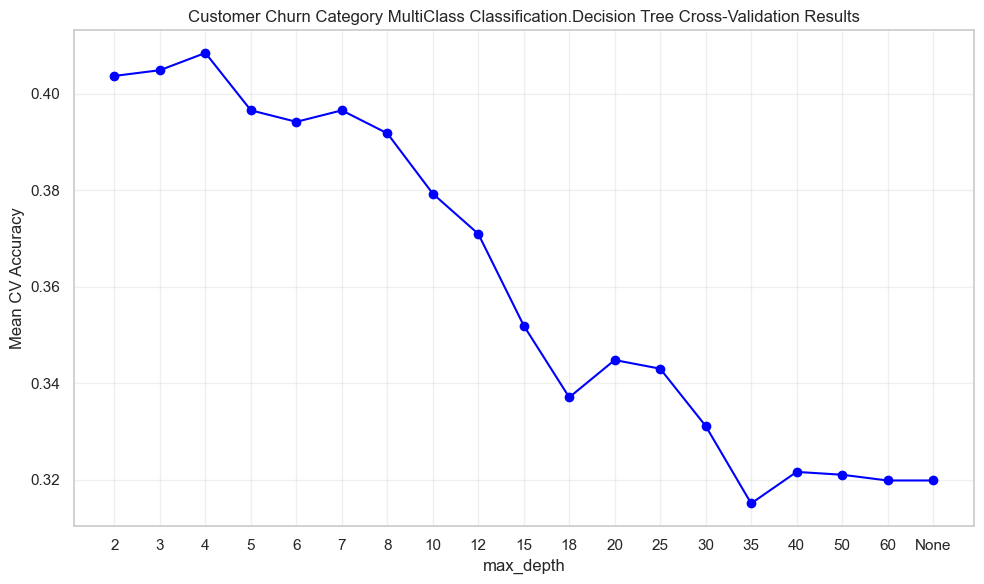

Churn category Decision Tree best max depth: 4
Churn category Decision Tree best mean CV accuracy: 0.4084


In [22]:
plot_cv_results(
    decision_tree_depths,
    churn_category_decision_tree_scores,
    title="Customer Churn Category MultiClass Classification.Decision Tree Cross-Validation Results",
    xlabel="max_depth",
    color="blue",
    save_name="churn_category_decision_tree_cv.png"
)
print("Churn category Decision Tree best max depth:", churn_category_decision_tree_grid.best_params_["model__max_depth"])
print("Churn category Decision Tree best mean CV accuracy:", round(churn_category_decision_tree_grid.best_score_, 4))

Next, I will tune the Random Forest model on the grouped churn category training dataset. To reduce the severe overfitting I saw earlier, I will keep the forest more constrained and tune the tree depth while holding the stronger regularization settings fixed.

In [23]:
churn_category_random_forest_pipeline = Pipeline(steps=[
    ("preprocessor", churn_category_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

churn_category_random_forest_grid = GridSearchCV(
    churn_category_random_forest_pipeline,
    param_grid={"model__max_depth": churn_category_random_forest_depths},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

churn_category_random_forest_grid.fit(X_train_churn_category, y_train_churn_category)
churn_category_random_forest_results = pd.DataFrame(churn_category_random_forest_grid.cv_results_)
churn_category_random_forest_scores = churn_category_random_forest_results["mean_test_score"].tolist()

print("Churn category Random Forest best parameter:", churn_category_random_forest_grid.best_params_["model__max_depth"])
print("Churn category Random Forest best mean CV accuracy:", round(churn_category_random_forest_grid.best_score_, 4))

Churn category Random Forest best parameter: 25
Churn category Random Forest best mean CV accuracy: 0.4043


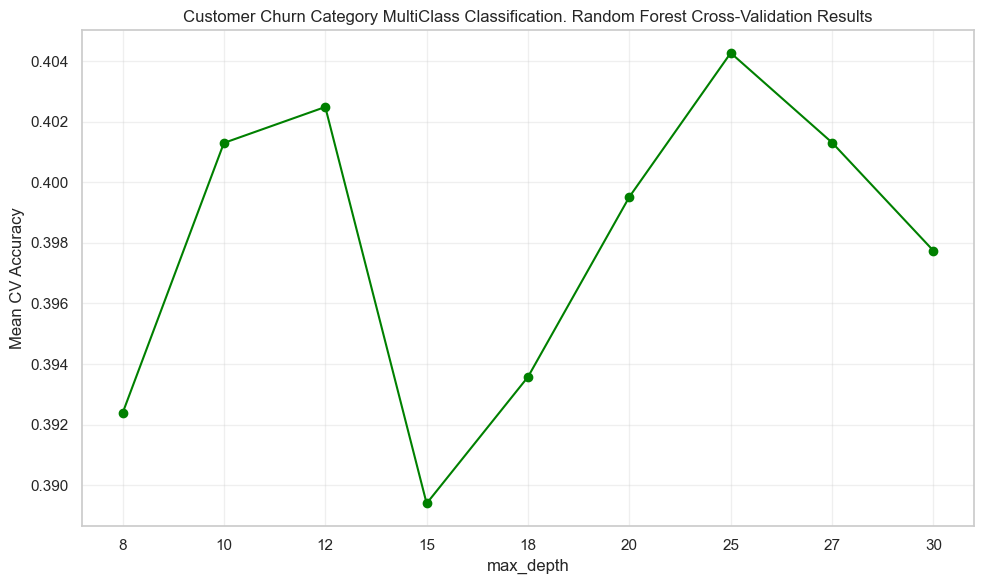

Churn category Random Forest best max depth: 25
Churn category Random Forest best mean CV accuracy: 0.4043


In [24]:
plot_cv_results(
    churn_category_random_forest_depths,
    churn_category_random_forest_scores,
    title="Customer Churn Category MultiClass Classification. Random Forest Cross-Validation Results",
    xlabel="max_depth",
    color="green",
    save_name="churn_category_random_forest_cv.png"
)
print("Churn category Random Forest best max depth:", churn_category_random_forest_grid.best_params_["model__max_depth"])
print("Churn category Random Forest best mean CV accuracy:", round(churn_category_random_forest_grid.best_score_, 4))

In [25]:
print("Best hyperparameter values for the churn category problem:")
print("Decision Tree max_depth =", churn_category_decision_tree_grid.best_params_["model__max_depth"])
print("Random Forest max_depth =", churn_category_random_forest_grid.best_params_["model__max_depth"])

Best hyperparameter values for the churn category problem:
Decision Tree max_depth = 4
Random Forest max_depth = 25


Now that I have the best hyperparameter values from cross-validation, I will train each final model on the full training set and then evaluate it on the holdout validation set. I will report training accuracy, training error, validation accuracy, validation error, macro F1 score, and the runtimes for both training and testing.


I will first do the final training and validation step for the churn classification problem.


In [26]:
X_val_churn = churn_test_df.drop(columns=["Churn Label"])
y_val_churn = churn_test_df["Churn Label"]

best_churn_decision_tree = Pipeline(steps=[
    ("preprocessor", churn_preprocessor),
    ("model", DecisionTreeClassifier(max_depth=churn_decision_tree_grid.best_params_["model__max_depth"], random_state=42))
])

start_train = time.perf_counter()
best_churn_decision_tree.fit(X_train_churn, y_train_churn)
churn_decision_tree_train_time = time.perf_counter() - start_train

churn_decision_tree_train_preds = best_churn_decision_tree.predict(X_train_churn)
churn_decision_tree_train_accuracy = accuracy_score(y_train_churn, churn_decision_tree_train_preds)
churn_decision_tree_train_error = 1 - churn_decision_tree_train_accuracy

start_test = time.perf_counter()
churn_decision_tree_val_preds = best_churn_decision_tree.predict(X_val_churn)
churn_decision_tree_test_time = time.perf_counter() - start_test

churn_decision_tree_val_accuracy = accuracy_score(y_val_churn, churn_decision_tree_val_preds)
churn_decision_tree_val_error = 1 - churn_decision_tree_val_accuracy
churn_decision_tree_val_macro_f1 = f1_score(y_val_churn, churn_decision_tree_val_preds, average="macro")

print("Churn problem Decision Tree training accuracy:", round(churn_decision_tree_train_accuracy, 4))
print("Churn problem Decision Tree training error:", round(churn_decision_tree_train_error, 4))
print("Churn problem Decision Tree training runtime:", round(churn_decision_tree_train_time, 4), "seconds")
print("Churn problem Decision Tree validation accuracy:", round(churn_decision_tree_val_accuracy, 4))
print("Churn problem Decision Tree validation error:", round(churn_decision_tree_val_error, 4))
print("Churn problem Decision Tree validation macro F1:", round(churn_decision_tree_val_macro_f1, 4))
print("Churn problem Decision Tree testing runtime:", round(churn_decision_tree_test_time, 4), "seconds")


Churn problem Decision Tree training accuracy: 0.8037
Churn problem Decision Tree training error: 0.1963
Churn problem Decision Tree training runtime: 0.052 seconds
Churn problem Decision Tree validation accuracy: 0.8
Churn problem Decision Tree validation error: 0.2
Churn problem Decision Tree validation macro F1: 0.7375
Churn problem Decision Tree testing runtime: 0.0047 seconds


In [27]:
best_churn_random_forest = Pipeline(steps=[
    ("preprocessor", churn_preprocessor),
    ("model", RandomForestClassifier(n_estimators=churn_random_forest_grid.best_params_["model__n_estimators"], random_state=42, n_jobs=-1))
])

start_train = time.perf_counter()
best_churn_random_forest.fit(X_train_churn, y_train_churn)
churn_random_forest_train_time = time.perf_counter() - start_train

churn_random_forest_train_preds = best_churn_random_forest.predict(X_train_churn)
churn_random_forest_train_accuracy = accuracy_score(y_train_churn, churn_random_forest_train_preds)
churn_random_forest_train_error = 1 - churn_random_forest_train_accuracy

start_test = time.perf_counter()
churn_random_forest_val_preds = best_churn_random_forest.predict(X_val_churn)
churn_random_forest_test_time = time.perf_counter() - start_test

churn_random_forest_val_accuracy = accuracy_score(y_val_churn, churn_random_forest_val_preds)
churn_random_forest_val_error = 1 - churn_random_forest_val_accuracy
churn_random_forest_val_macro_f1 = f1_score(y_val_churn, churn_random_forest_val_preds, average="macro")

print("Churn problem Random Forest training accuracy:", round(churn_random_forest_train_accuracy, 4))
print("Churn problem Random Forest training error:", round(churn_random_forest_train_error, 4))
print("Churn problem Random Forest training runtime:", round(churn_random_forest_train_time, 4), "seconds")
print("Churn problem Random Forest validation accuracy:", round(churn_random_forest_val_accuracy, 4))
print("Churn problem Random Forest validation error:", round(churn_random_forest_val_error, 4))
print("Churn problem Random Forest validation macro F1:", round(churn_random_forest_val_macro_f1, 4))
print("Churn problem Random Forest testing runtime:", round(churn_random_forest_test_time, 4), "seconds")


Churn problem Random Forest training accuracy: 1.0
Churn problem Random Forest training error: 0.0
Churn problem Random Forest training runtime: 0.3671 seconds
Churn problem Random Forest validation accuracy: 0.8071
Churn problem Random Forest validation error: 0.1929
Churn problem Random Forest validation macro F1: 0.7287
Churn problem Random Forest testing runtime: 0.014 seconds


Next, I will do the final training and validation step for the grouped churn category problem using the engineered features and the updated Random Forest settings.

In [28]:
best_churn_category_decision_tree = Pipeline(steps=[
    ("preprocessor", churn_category_preprocessor),
    ("model", DecisionTreeClassifier(max_depth=churn_category_decision_tree_grid.best_params_["model__max_depth"], random_state=42))
])

start_train = time.perf_counter()
best_churn_category_decision_tree.fit(X_train_churn_category, y_train_churn_category)
churn_category_decision_tree_train_time = time.perf_counter() - start_train

churn_category_decision_tree_train_preds = best_churn_category_decision_tree.predict(X_train_churn_category)
churn_category_decision_tree_train_accuracy = accuracy_score(y_train_churn_category, churn_category_decision_tree_train_preds)
churn_category_decision_tree_train_error = 1 - churn_category_decision_tree_train_accuracy

start_test = time.perf_counter()
churn_category_decision_tree_val_preds = best_churn_category_decision_tree.predict(X_val_churn_category)
churn_category_decision_tree_test_time = time.perf_counter() - start_test

churn_category_decision_tree_val_accuracy = accuracy_score(y_val_churn_category, churn_category_decision_tree_val_preds)
churn_category_decision_tree_val_error = 1 - churn_category_decision_tree_val_accuracy
churn_category_decision_tree_val_macro_f1 = f1_score(y_val_churn_category, churn_category_decision_tree_val_preds, average="macro")

print("Churn category Decision Tree training accuracy:", round(churn_category_decision_tree_train_accuracy, 4))
print("Churn category Decision Tree training error:", round(churn_category_decision_tree_train_error, 4))
print("Churn category Decision Tree training runtime:", round(churn_category_decision_tree_train_time, 4), "seconds")
print("Churn category Decision Tree validation accuracy:", round(churn_category_decision_tree_val_accuracy, 4))
print("Churn category Decision Tree validation error:", round(churn_category_decision_tree_val_error, 4))
print("Churn category Decision Tree validation macro F1:", round(churn_category_decision_tree_val_macro_f1, 4))
print("Churn category Decision Tree testing runtime:", round(churn_category_decision_tree_test_time, 4), "seconds")

Churn category Decision Tree training accuracy: 0.4322
Churn category Decision Tree training error: 0.5678
Churn category Decision Tree training runtime: 0.0147 seconds
Churn category Decision Tree validation accuracy: 0.4118
Churn category Decision Tree validation error: 0.5882
Churn category Decision Tree validation macro F1: 0.1748
Churn category Decision Tree testing runtime: 0.0029 seconds


In [29]:
best_churn_category_random_forest = Pipeline(steps=[
    ("preprocessor", churn_category_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        max_depth=churn_category_random_forest_grid.best_params_["model__max_depth"],
        min_samples_split=2,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

start_train = time.perf_counter()
best_churn_category_random_forest.fit(X_train_churn_category, y_train_churn_category)
churn_category_random_forest_train_time = time.perf_counter() - start_train

churn_category_random_forest_train_preds = best_churn_category_random_forest.predict(X_train_churn_category)
churn_category_random_forest_train_accuracy = accuracy_score(y_train_churn_category, churn_category_random_forest_train_preds)
churn_category_random_forest_train_error = 1 - churn_category_random_forest_train_accuracy

start_test = time.perf_counter()
churn_category_random_forest_val_preds = best_churn_category_random_forest.predict(X_val_churn_category)
churn_category_random_forest_test_time = time.perf_counter() - start_test

churn_category_random_forest_val_accuracy = accuracy_score(y_val_churn_category, churn_category_random_forest_val_preds)
churn_category_random_forest_val_error = 1 - churn_category_random_forest_val_accuracy
churn_category_random_forest_val_macro_f1 = f1_score(y_val_churn_category, churn_category_random_forest_val_preds, average="macro")

print("Churn category Random Forest training accuracy:", round(churn_category_random_forest_train_accuracy, 4))
print("Churn category Random Forest training error:", round(churn_category_random_forest_train_error, 4))
print("Churn category Random Forest training runtime:", round(churn_category_random_forest_train_time, 4), "seconds")
print("Churn category Random Forest validation accuracy:", round(churn_category_random_forest_val_accuracy, 4))
print("Churn category Random Forest validation error:", round(churn_category_random_forest_val_error, 4))
print("Churn category Random Forest validation macro F1:", round(churn_category_random_forest_val_macro_f1, 4))
print("Churn category Random Forest testing runtime:", round(churn_category_random_forest_test_time, 4), "seconds")

Churn category Random Forest training accuracy: 0.648
Churn category Random Forest training error: 0.352
Churn category Random Forest training runtime: 0.09 seconds
Churn category Random Forest validation accuracy: 0.4439
Churn category Random Forest validation error: 0.5561
Churn category Random Forest validation macro F1: 0.2281
Churn category Random Forest testing runtime: 0.0097 seconds


### Part C (Dimension Reduction)

I will first reduce the churn training and validation sets by half using Principal Component Analysis (PCA). After one-hot encoding the categorical predictors and standardizing the encoded feature matrix, I will keep half of the original processed predictor columns as principal components. The response variable will still be kept as the last column in the saved reduced datasets.


In [30]:
X_train_churn = churn_train_df.drop(columns=["Churn Label"])
y_train_churn = churn_train_df["Churn Label"]
X_val_churn = churn_test_df.drop(columns=["Churn Label"])
y_val_churn = churn_test_df["Churn Label"]

categorical_cols_churn = X_train_churn.select_dtypes(include="object").columns.tolist()
numeric_cols_churn = X_train_churn.select_dtypes(exclude="object").columns.tolist()


churn_reduction_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols_churn),
        ("numeric", "passthrough", numeric_cols_churn)
    ]
)

X_train_churn_encoded = churn_reduction_preprocessor.fit_transform(X_train_churn)
X_val_churn_encoded = churn_reduction_preprocessor.transform(X_val_churn)

if hasattr(X_train_churn_encoded, "toarray"):
    X_train_churn_encoded_array = X_train_churn_encoded.toarray()
    X_val_churn_encoded_array = X_val_churn_encoded.toarray()
else:
    X_train_churn_encoded_array = X_train_churn_encoded
    X_val_churn_encoded_array = X_val_churn_encoded

churn_scaler = StandardScaler()
X_train_churn_scaled = churn_scaler.fit_transform(X_train_churn_encoded_array)
X_val_churn_scaled = churn_scaler.transform(X_val_churn_encoded_array)

churn_k_features = X_train_churn.shape[1] // 2
churn_pca = PCA(n_components=churn_k_features, random_state=42)
X_train_churn_reduced = churn_pca.fit_transform(X_train_churn_scaled)
X_val_churn_reduced = churn_pca.transform(X_val_churn_scaled)

churn_component_names = [f"PC{i}" for i in range(1, churn_k_features + 1)]
churn_train_reduced_df = pd.DataFrame(X_train_churn_reduced, columns=churn_component_names)
churn_test_reduced_df = pd.DataFrame(X_val_churn_reduced, columns=churn_component_names)

churn_train_reduced_df["Churn Label"] = y_train_churn.reset_index(drop=True)
churn_test_reduced_df["Churn Label"] = y_val_churn.reset_index(drop=True)

churn_train_reduced_df.to_csv(f"{processed_dir}/churn_train_reduced.csv", index=False)
churn_test_reduced_df.to_csv(f"{processed_dir}/churn_test_reduced.csv", index=False)

print("Original churn predictor count:", X_train_churn.shape[1])
print("Reduced churn feature count:", churn_k_features)
print("Reduced churn training shape:", churn_train_reduced_df.shape)
print("Reduced churn validation shape:", churn_test_reduced_df.shape)


Original churn predictor count: 21
Reduced churn feature count: 10
Reduced churn training shape: (6338, 11)
Reduced churn validation shape: (705, 11)


In [31]:
def plot_cross_validation_results_reduced(param_values, mean_scores, title, xlabel, color, save_name):
    plt.figure(figsize=(10, 6))
    plot_values = ["None" if value is None else str(value) for value in param_values]
    plt.plot(plot_values, mean_scores, marker="o", color=color)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Mean CV Accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Next, I will tune the Decision Tree and Random Forest models on the reduced churn dataset using 5-fold cross-validation.

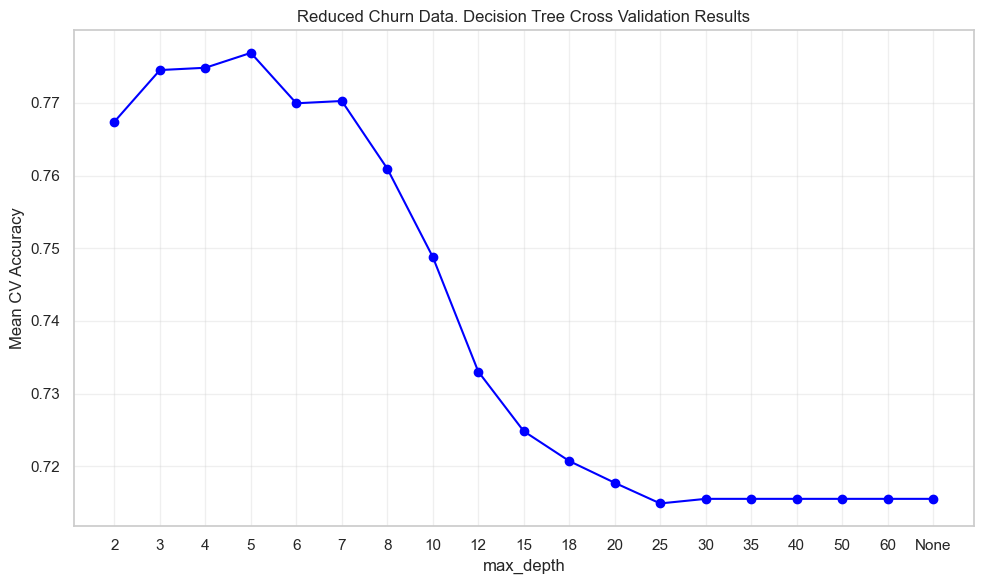

Reduced churn Decision Tree best parameter: 5
Reduced churn Decision Tree best mean CV accuracy: 0.7769


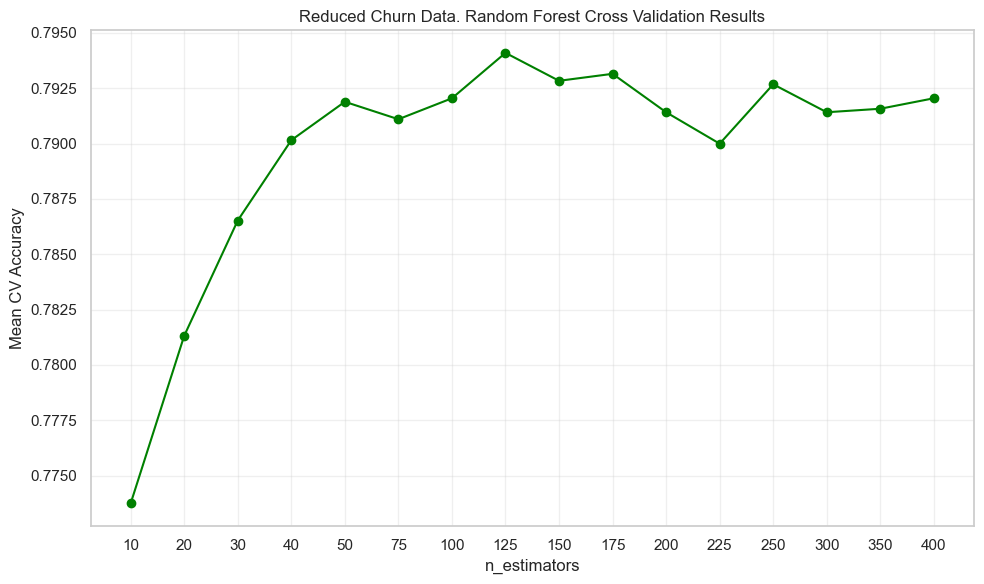

Reduced churn Random Forest best parameter: 125
Reduced churn Random Forest best mean CV accuracy: 0.7941


In [32]:
X_train_churn_reduced_model = churn_train_reduced_df.drop(columns=["Churn Label"])
y_train_churn_reduced_model = churn_train_reduced_df["Churn Label"]

churn_reduced_decision_tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={"max_depth": decision_tree_depths},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

churn_reduced_decision_tree_grid.fit(X_train_churn_reduced_model, y_train_churn_reduced_model)
churn_reduced_decision_tree_scores = churn_reduced_decision_tree_grid.cv_results_["mean_test_score"].tolist()

plot_cross_validation_results_reduced(
    decision_tree_depths,
    churn_reduced_decision_tree_scores,
    title="Reduced Churn Data. Decision Tree Cross Validation Results",
    xlabel="max_depth",
    color="blue",
    save_name="churn_reduced_decision_tree_cv.png"
)

print("Reduced churn Decision Tree best parameter:", churn_reduced_decision_tree_grid.best_params_["max_depth"])
print("Reduced churn Decision Tree best mean CV accuracy:", round(churn_reduced_decision_tree_grid.best_score_, 4))

churn_reduced_random_forest_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid={"n_estimators": random_forest_estimators},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

churn_reduced_random_forest_grid.fit(X_train_churn_reduced_model, y_train_churn_reduced_model)
churn_reduced_random_forest_scores = churn_reduced_random_forest_grid.cv_results_["mean_test_score"].tolist()

plot_cross_validation_results_reduced(
    random_forest_estimators,
    churn_reduced_random_forest_scores,
    title="Reduced Churn Data. Random Forest Cross Validation Results",
    xlabel="n_estimators",
    color="green",
    save_name="churn_reduced_random_forest_cv.png"
)

print("Reduced churn Random Forest best parameter:", churn_reduced_random_forest_grid.best_params_["n_estimators"])
print("Reduced churn Random Forest best mean CV accuracy:", round(churn_reduced_random_forest_grid.best_score_, 4))


Now I will train the final reduced-data churn models on the full reduced training set and evaluate them on the reduced validation set.

In [33]:
X_val_churn_reduced_model = churn_test_reduced_df.drop(columns=["Churn Label"])
y_val_churn_reduced_model = churn_test_reduced_df["Churn Label"]

best_churn_reduced_decision_tree = DecisionTreeClassifier(
    max_depth=churn_reduced_decision_tree_grid.best_params_["max_depth"],
    random_state=42
)

start_train = time.perf_counter()
best_churn_reduced_decision_tree.fit(X_train_churn_reduced_model, y_train_churn_reduced_model)
churn_reduced_decision_tree_train_time = time.perf_counter() - start_train

churn_reduced_decision_tree_train_preds = best_churn_reduced_decision_tree.predict(X_train_churn_reduced_model)
churn_reduced_decision_tree_train_accuracy = accuracy_score(y_train_churn_reduced_model, churn_reduced_decision_tree_train_preds)
churn_reduced_decision_tree_train_error = 1 - churn_reduced_decision_tree_train_accuracy

start_test = time.perf_counter()
churn_reduced_decision_tree_val_preds = best_churn_reduced_decision_tree.predict(X_val_churn_reduced_model)
churn_reduced_decision_tree_test_time = time.perf_counter() - start_test

churn_reduced_decision_tree_val_accuracy = accuracy_score(y_val_churn_reduced_model, churn_reduced_decision_tree_val_preds)
churn_reduced_decision_tree_val_error = 1 - churn_reduced_decision_tree_val_accuracy
churn_reduced_decision_tree_val_macro_f1 = f1_score(y_val_churn_reduced_model, churn_reduced_decision_tree_val_preds, average="macro")

print("Reduced churn Decision Tree training accuracy:", round(churn_reduced_decision_tree_train_accuracy, 4))
print("Reduced churn Decision Tree training error:", round(churn_reduced_decision_tree_train_error, 4))
print("Reduced churn Decision Tree training runtime:", round(churn_reduced_decision_tree_train_time, 4), "seconds")
print("Reduced churn Decision Tree validation accuracy:", round(churn_reduced_decision_tree_val_accuracy, 4))
print("Reduced churn Decision Tree validation error:", round(churn_reduced_decision_tree_val_error, 4))
print("Reduced churn Decision Tree validation macro F1:", round(churn_reduced_decision_tree_val_macro_f1, 4))
print("Reduced churn Decision Tree testing runtime:", round(churn_reduced_decision_tree_test_time, 4), "seconds")

best_churn_reduced_random_forest = RandomForestClassifier(
    n_estimators=churn_reduced_random_forest_grid.best_params_["n_estimators"],
    random_state=42,
    n_jobs=-1
)

start_train = time.perf_counter()
best_churn_reduced_random_forest.fit(X_train_churn_reduced_model, y_train_churn_reduced_model)
churn_reduced_random_forest_train_time = time.perf_counter() - start_train

churn_reduced_random_forest_train_preds = best_churn_reduced_random_forest.predict(X_train_churn_reduced_model)
churn_reduced_random_forest_train_accuracy = accuracy_score(y_train_churn_reduced_model, churn_reduced_random_forest_train_preds)
churn_reduced_random_forest_train_error = 1 - churn_reduced_random_forest_train_accuracy

start_test = time.perf_counter()
churn_reduced_random_forest_val_preds = best_churn_reduced_random_forest.predict(X_val_churn_reduced_model)
churn_reduced_random_forest_test_time = time.perf_counter() - start_test

churn_reduced_random_forest_val_accuracy = accuracy_score(y_val_churn_reduced_model, churn_reduced_random_forest_val_preds)
churn_reduced_random_forest_val_error = 1 - churn_reduced_random_forest_val_accuracy
churn_reduced_random_forest_val_macro_f1 = f1_score(y_val_churn_reduced_model, churn_reduced_random_forest_val_preds, average="macro")

print("Reduced churn Random Forest training accuracy:", round(churn_reduced_random_forest_train_accuracy, 4))
print("Reduced churn Random Forest training error:", round(churn_reduced_random_forest_train_error, 4))
print("Reduced churn Random Forest training runtime:", round(churn_reduced_random_forest_train_time, 4), "seconds")
print("Reduced churn Random Forest validation accuracy:", round(churn_reduced_random_forest_val_accuracy, 4))
print("Reduced churn Random Forest validation error:", round(churn_reduced_random_forest_val_error, 4))
print("Reduced churn Random Forest validation macro F1:", round(churn_reduced_random_forest_val_macro_f1, 4))
print("Reduced churn Random Forest testing runtime:", round(churn_reduced_random_forest_test_time, 4), "seconds")


Reduced churn Decision Tree training accuracy: 0.7974
Reduced churn Decision Tree training error: 0.2026
Reduced churn Decision Tree training runtime: 0.0429 seconds
Reduced churn Decision Tree validation accuracy: 0.783
Reduced churn Decision Tree validation error: 0.217
Reduced churn Decision Tree validation macro F1: 0.6753
Reduced churn Decision Tree testing runtime: 0.0004 seconds
Reduced churn Random Forest training accuracy: 1.0
Reduced churn Random Forest training error: 0.0
Reduced churn Random Forest training runtime: 0.3646 seconds
Reduced churn Random Forest validation accuracy: 0.7858
Reduced churn Random Forest validation error: 0.2142
Reduced churn Random Forest validation macro F1: 0.6928
Reduced churn Random Forest testing runtime: 0.0147 seconds


I will now repeat the same dimension reduction process for the grouped churn category problem. After engineering the Part B features, I will one-hot encode the categorical columns, standardize the encoded feature matrix, and use PCA to keep half of the original processed predictor columns as principal components. I will again save the response variable as the last column.


In [34]:
X_train_churn_category_base = churn_category_train_df.drop(columns=["Churn Category"])
y_train_churn_category = churn_category_train_df["Churn Category"]
X_val_churn_category_base = churn_category_test_df.drop(columns=["Churn Category"])
y_val_churn_category = churn_category_test_df["Churn Category"]

X_train_churn_category = add_churn_reason_features(X_train_churn_category_base)
X_val_churn_category = add_churn_reason_features(X_val_churn_category_base)

categorical_cols_churn_category = X_train_churn_category.select_dtypes(include="object").columns.tolist()
numeric_cols_churn_category = X_train_churn_category.select_dtypes(exclude="object").columns.tolist()

churn_category_reduction_preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols_churn_category),
        ("numeric", "passthrough", numeric_cols_churn_category)
    ]
)

X_train_churn_category_encoded = churn_category_reduction_preprocessor.fit_transform(X_train_churn_category)
X_val_churn_category_encoded = churn_category_reduction_preprocessor.transform(X_val_churn_category)

if hasattr(X_train_churn_category_encoded, "toarray"):
    X_train_churn_category_encoded_array = X_train_churn_category_encoded.toarray()
    X_val_churn_category_encoded_array = X_val_churn_category_encoded.toarray()
else:
    X_train_churn_category_encoded_array = X_train_churn_category_encoded
    X_val_churn_category_encoded_array = X_val_churn_category_encoded

churn_category_scaler = StandardScaler()
X_train_churn_category_scaled = churn_category_scaler.fit_transform(X_train_churn_category_encoded_array)
X_val_churn_category_scaled = churn_category_scaler.transform(X_val_churn_category_encoded_array)

churn_category_k_features = X_train_churn_category_base.shape[1] // 2
churn_category_pca = PCA(n_components=churn_category_k_features, random_state=42)
X_train_churn_category_reduced = churn_category_pca.fit_transform(X_train_churn_category_scaled)
X_val_churn_category_reduced = churn_category_pca.transform(X_val_churn_category_scaled)

churn_category_component_names = [f"PC{i}" for i in range(1, churn_category_k_features + 1)]
churn_category_train_reduced_df = pd.DataFrame(X_train_churn_category_reduced, columns=churn_category_component_names)
churn_category_test_reduced_df = pd.DataFrame(X_val_churn_category_reduced, columns=churn_category_component_names)

churn_category_train_reduced_df["Churn Category"] = y_train_churn_category.reset_index(drop=True)
churn_category_test_reduced_df["Churn Category"] = y_val_churn_category.reset_index(drop=True)

churn_category_train_reduced_df.to_csv(f"{processed_dir}/churn_category_train_reduced.csv", index=False)
churn_category_test_reduced_df.to_csv(f"{processed_dir}/churn_category_test_reduced.csv", index=False)

print("Original churn category predictor count:", X_train_churn_category_base.shape[1])
print("Reduced churn category feature count:", churn_category_k_features)
print("Reduced churn category training shape:", churn_category_train_reduced_df.shape)
print("Reduced churn category validation shape:", churn_category_test_reduced_df.shape)


Original churn category predictor count: 21
Reduced churn category feature count: 10
Reduced churn category training shape: (1682, 11)
Reduced churn category validation shape: (187, 11)


Next, I will tune the Decision Tree and Random Forest models on the reduced churn category dataset using 5-fold cross-validation.

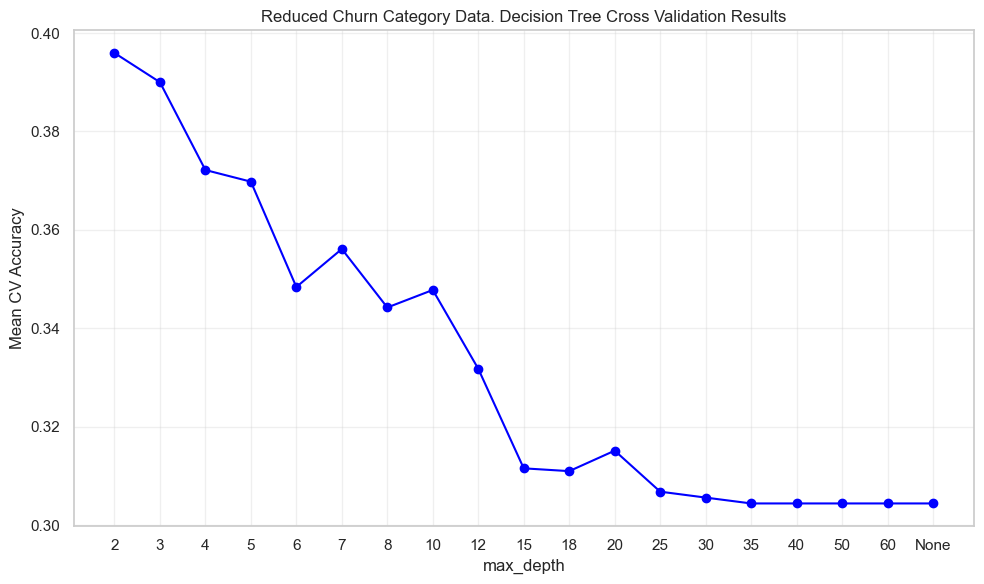

Reduced churn category Decision Tree best max_depth: 2
Reduced churn category Decision Tree best mean CV accuracy: 0.396


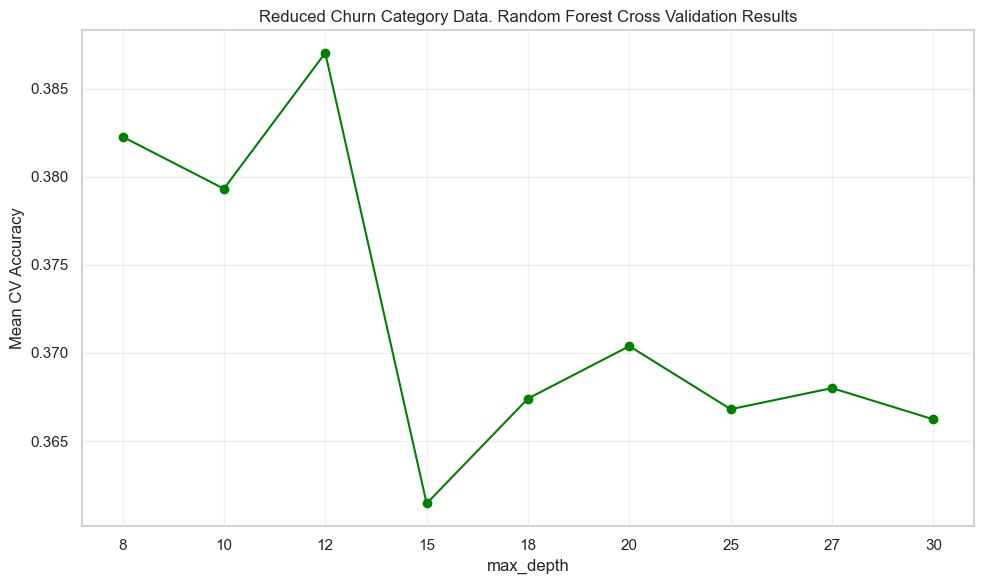

Reduced churn category Random Forest best max_depth: 12
Reduced churn category Random Forest best mean CV accuracy: 0.387


In [35]:
X_train_churn_category_reduced_model = churn_category_train_reduced_df.drop(columns=["Churn Category"])
y_train_churn_category_reduced_model = churn_category_train_reduced_df["Churn Category"]

churn_category_reduced_decision_tree_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid={"max_depth": decision_tree_depths},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

churn_category_reduced_decision_tree_grid.fit(X_train_churn_category_reduced_model, y_train_churn_category_reduced_model)
churn_category_reduced_decision_tree_scores = churn_category_reduced_decision_tree_grid.cv_results_["mean_test_score"].tolist()

plot_cross_validation_results_reduced(
    decision_tree_depths,
    churn_category_reduced_decision_tree_scores,
    title="Reduced Churn Category Data. Decision Tree Cross Validation Results",
    xlabel="max_depth",
    color="blue",
    save_name="churn_category_reduced_decision_tree_cv.png"
)

print("Reduced churn category Decision Tree best max_depth:", churn_category_reduced_decision_tree_grid.best_params_["max_depth"])
print("Reduced churn category Decision Tree best mean CV accuracy:", round(churn_category_reduced_decision_tree_grid.best_score_, 4))

churn_category_reduced_random_forest_grid = GridSearchCV(
    RandomForestClassifier(
        n_estimators=100,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ),
    param_grid={"max_depth": churn_category_random_forest_depths},
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

churn_category_reduced_random_forest_grid.fit(X_train_churn_category_reduced_model, y_train_churn_category_reduced_model)
churn_category_reduced_random_forest_scores = churn_category_reduced_random_forest_grid.cv_results_["mean_test_score"].tolist()

plot_cross_validation_results_reduced(
    churn_category_random_forest_depths,
    churn_category_reduced_random_forest_scores,
    title="Reduced Churn Category Data. Random Forest Cross Validation Results",
    xlabel="max_depth",
    color="green",
    save_name="churn_category_reduced_random_forest_cv.png"
)

print("Reduced churn category Random Forest best max_depth:", churn_category_reduced_random_forest_grid.best_params_["max_depth"])
print("Reduced churn category Random Forest best mean CV accuracy:", round(churn_category_reduced_random_forest_grid.best_score_, 4))

Finally, I will train the reduced-data churn category models on the full reduced training set and evaluate them on the reduced validation set.

In [36]:
X_val_churn_category_reduced_model = churn_category_test_reduced_df.drop(columns=["Churn Category"])
y_val_churn_category_reduced_model = churn_category_test_reduced_df["Churn Category"]

best_churn_category_reduced_decision_tree = DecisionTreeClassifier(
    max_depth=churn_category_reduced_decision_tree_grid.best_params_["max_depth"],
    random_state=42
)

start_train = time.perf_counter()
best_churn_category_reduced_decision_tree.fit(X_train_churn_category_reduced_model, y_train_churn_category_reduced_model)
churn_category_reduced_decision_tree_train_time = time.perf_counter() - start_train

churn_category_reduced_decision_tree_train_preds = best_churn_category_reduced_decision_tree.predict(X_train_churn_category_reduced_model)
churn_category_reduced_decision_tree_train_accuracy = accuracy_score(y_train_churn_category_reduced_model, churn_category_reduced_decision_tree_train_preds)
churn_category_reduced_decision_tree_train_error = 1 - churn_category_reduced_decision_tree_train_accuracy

start_test = time.perf_counter()
churn_category_reduced_decision_tree_val_preds = best_churn_category_reduced_decision_tree.predict(X_val_churn_category_reduced_model)
churn_category_reduced_decision_tree_test_time = time.perf_counter() - start_test

churn_category_reduced_decision_tree_val_accuracy = accuracy_score(y_val_churn_category_reduced_model, churn_category_reduced_decision_tree_val_preds)
churn_category_reduced_decision_tree_val_error = 1 - churn_category_reduced_decision_tree_val_accuracy
churn_category_reduced_decision_tree_val_macro_f1 = f1_score(y_val_churn_category_reduced_model, churn_category_reduced_decision_tree_val_preds, average="macro")

print("Reduced churn category Decision Tree training accuracy:", round(churn_category_reduced_decision_tree_train_accuracy, 4))
print("Reduced churn category Decision Tree training error:", round(churn_category_reduced_decision_tree_train_error, 4))
print("Reduced churn category Decision Tree training runtime:", round(churn_category_reduced_decision_tree_train_time, 4), "seconds")
print("Reduced churn category Decision Tree validation accuracy:", round(churn_category_reduced_decision_tree_val_accuracy, 4))
print("Reduced churn category Decision Tree validation error:", round(churn_category_reduced_decision_tree_val_error, 4))
print("Reduced churn category Decision Tree validation macro F1:", round(churn_category_reduced_decision_tree_val_macro_f1, 4))
print("Reduced churn category Decision Tree testing runtime:", round(churn_category_reduced_decision_tree_test_time, 4), "seconds")

best_churn_category_reduced_random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=churn_category_reduced_random_forest_grid.best_params_["max_depth"],
    min_samples_split=2,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

start_train = time.perf_counter()
best_churn_category_reduced_random_forest.fit(X_train_churn_category_reduced_model, y_train_churn_category_reduced_model)
churn_category_reduced_random_forest_train_time = time.perf_counter() - start_train

churn_category_reduced_random_forest_train_preds = best_churn_category_reduced_random_forest.predict(X_train_churn_category_reduced_model)
churn_category_reduced_random_forest_train_accuracy = accuracy_score(y_train_churn_category_reduced_model, churn_category_reduced_random_forest_train_preds)
churn_category_reduced_random_forest_train_error = 1 - churn_category_reduced_random_forest_train_accuracy

start_test = time.perf_counter()
churn_category_reduced_random_forest_val_preds = best_churn_category_reduced_random_forest.predict(X_val_churn_category_reduced_model)
churn_category_reduced_random_forest_test_time = time.perf_counter() - start_test

churn_category_reduced_random_forest_val_accuracy = accuracy_score(y_val_churn_category_reduced_model, churn_category_reduced_random_forest_val_preds)
churn_category_reduced_random_forest_val_error = 1 - churn_category_reduced_random_forest_val_accuracy
churn_category_reduced_random_forest_val_macro_f1 = f1_score(y_val_churn_category_reduced_model, churn_category_reduced_random_forest_val_preds, average="macro")

print("Reduced churn category Random Forest training accuracy:", round(churn_category_reduced_random_forest_train_accuracy, 4))
print("Reduced churn category Random Forest training error:", round(churn_category_reduced_random_forest_train_error, 4))
print("Reduced churn category Random Forest training runtime:", round(churn_category_reduced_random_forest_train_time, 4), "seconds")
print("Reduced churn category Random Forest validation accuracy:", round(churn_category_reduced_random_forest_val_accuracy, 4))
print("Reduced churn category Random Forest validation error:", round(churn_category_reduced_random_forest_val_error, 4))
print("Reduced churn category Random Forest validation macro F1:", round(churn_category_reduced_random_forest_val_macro_f1, 4))
print("Reduced churn category Random Forest testing runtime:", round(churn_category_reduced_random_forest_test_time, 4), "seconds")

Reduced churn category Decision Tree training accuracy: 0.4019
Reduced churn category Decision Tree training error: 0.5981
Reduced churn category Decision Tree training runtime: 0.0046 seconds
Reduced churn category Decision Tree validation accuracy: 0.4011
Reduced churn category Decision Tree validation error: 0.5989
Reduced churn category Decision Tree validation macro F1: 0.1431
Reduced churn category Decision Tree testing runtime: 0.0003 seconds
Reduced churn category Random Forest training accuracy: 0.8264
Reduced churn category Random Forest training error: 0.1736
Reduced churn category Random Forest training runtime: 0.1298 seconds
Reduced churn category Random Forest validation accuracy: 0.3529
Reduced churn category Random Forest validation error: 0.6471
Reduced churn category Random Forest validation macro F1: 0.1786
Reduced churn category Random Forest testing runtime: 0.0076 seconds
